# Final CNN test evaluation

Uses the frozen epoch-25 checkpoint and fixed shared test split. No training, augmentation, or tuning. Completed results are loaded on reruns. Do not use these results to tune and claim a fresh holdout evaluation.


In [2]:
from pathlib import Path
import sys

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "dataset").is_dir() and (p / "src").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook inside the project repository.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Repository:", ROOT)


Repository: /Users/keerthikeerthi/Desktop/brain-tumor-mri-classification


In [3]:
from src.evaluation import evaluate_run
import pandas as pd
from IPython.display import display, Image

metrics, output = evaluate_run()
display(pd.Series(metrics))
display(pd.read_csv(output / "classification_report.csv", index_col=0))


test_images                                                          1001
accuracy                                                         0.947053
cross_entropy                                                    0.132358
macro_precision                                                  0.945921
macro_recall                                                     0.945898
macro_f1                                                         0.945593
macro_roc_auc_ovr                                                0.996681
checkpoint                   models/cnn_20260928T045158815871Z/best.keras
checkpoint_sha256       8b94cedf4256db39ae4f1648099eddab1527584f02060d...
test_manifest_sha256    9f717d2a7e51e4a9b4e380036a626a910ce79f3004bd9c...
class_to_index          {'glioma': 0, 'meningioma': 1, 'notumor': 2, '...
misclassified_images                                                   53
dtype: object

,precision,recall,f1-score,support
glioma,0.960317,0.909774,0.934363,266.000000
meningioma,0.909910,0.905830,0.907865,223.000000
notumor,0.964000,0.971774,0.967871,248.000000
pituitary,0.949458,0.996212,0.972274,264.000000
accuracy,0.947053,0.947053,0.947053,0.947053
macro avg,0.945921,0.945898,0.945593,1001.000000
weighted avg,0.947136,0.947053,0.946760,1001.000000


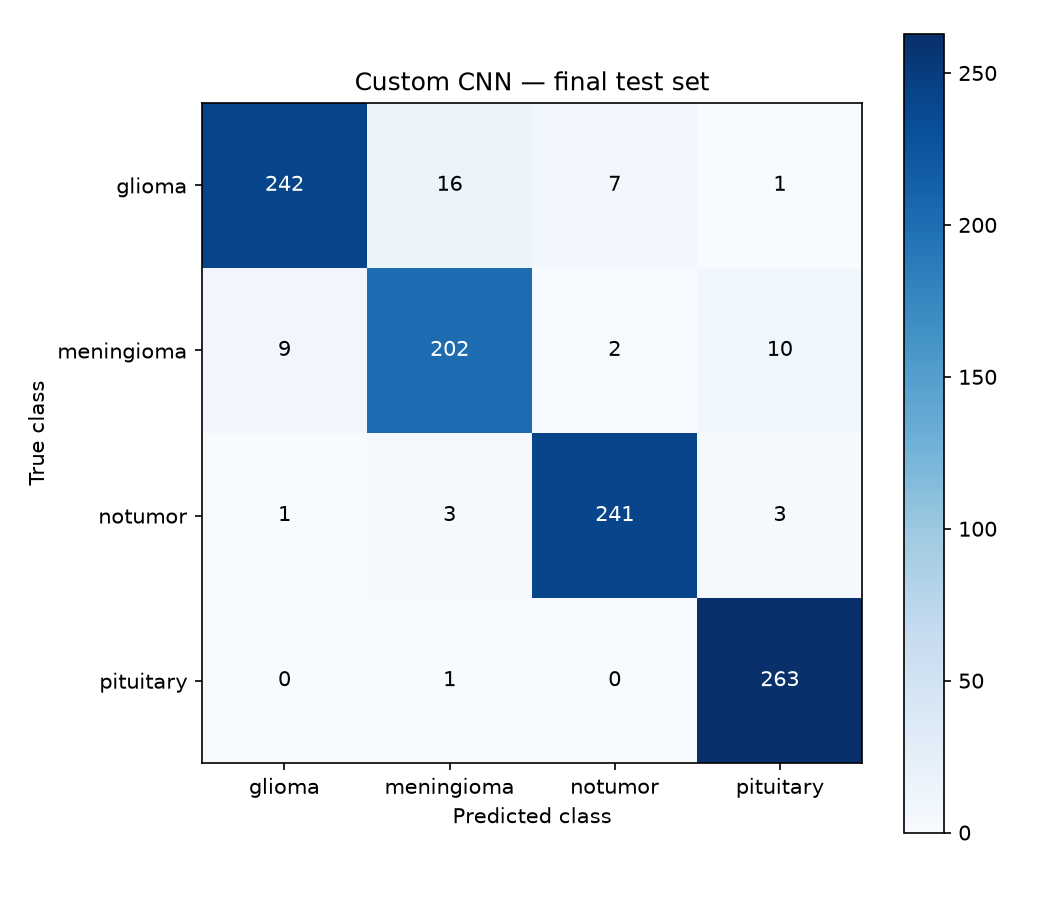

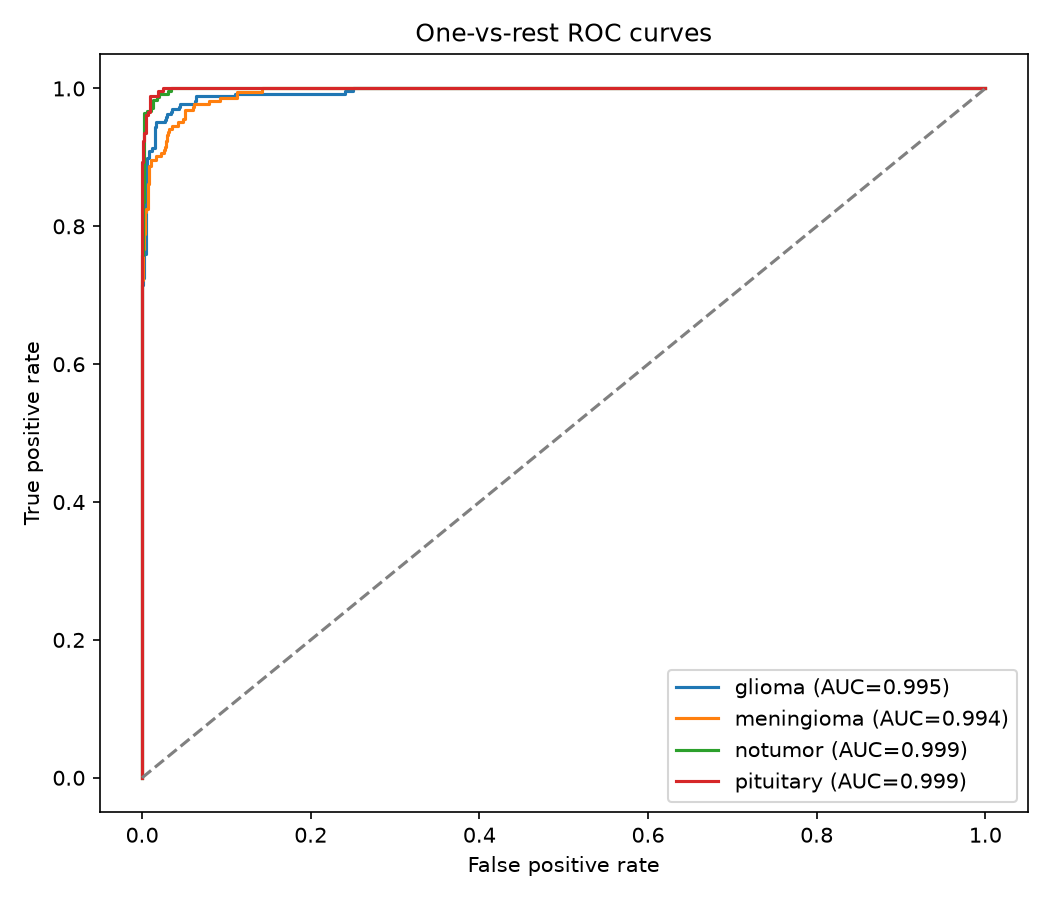

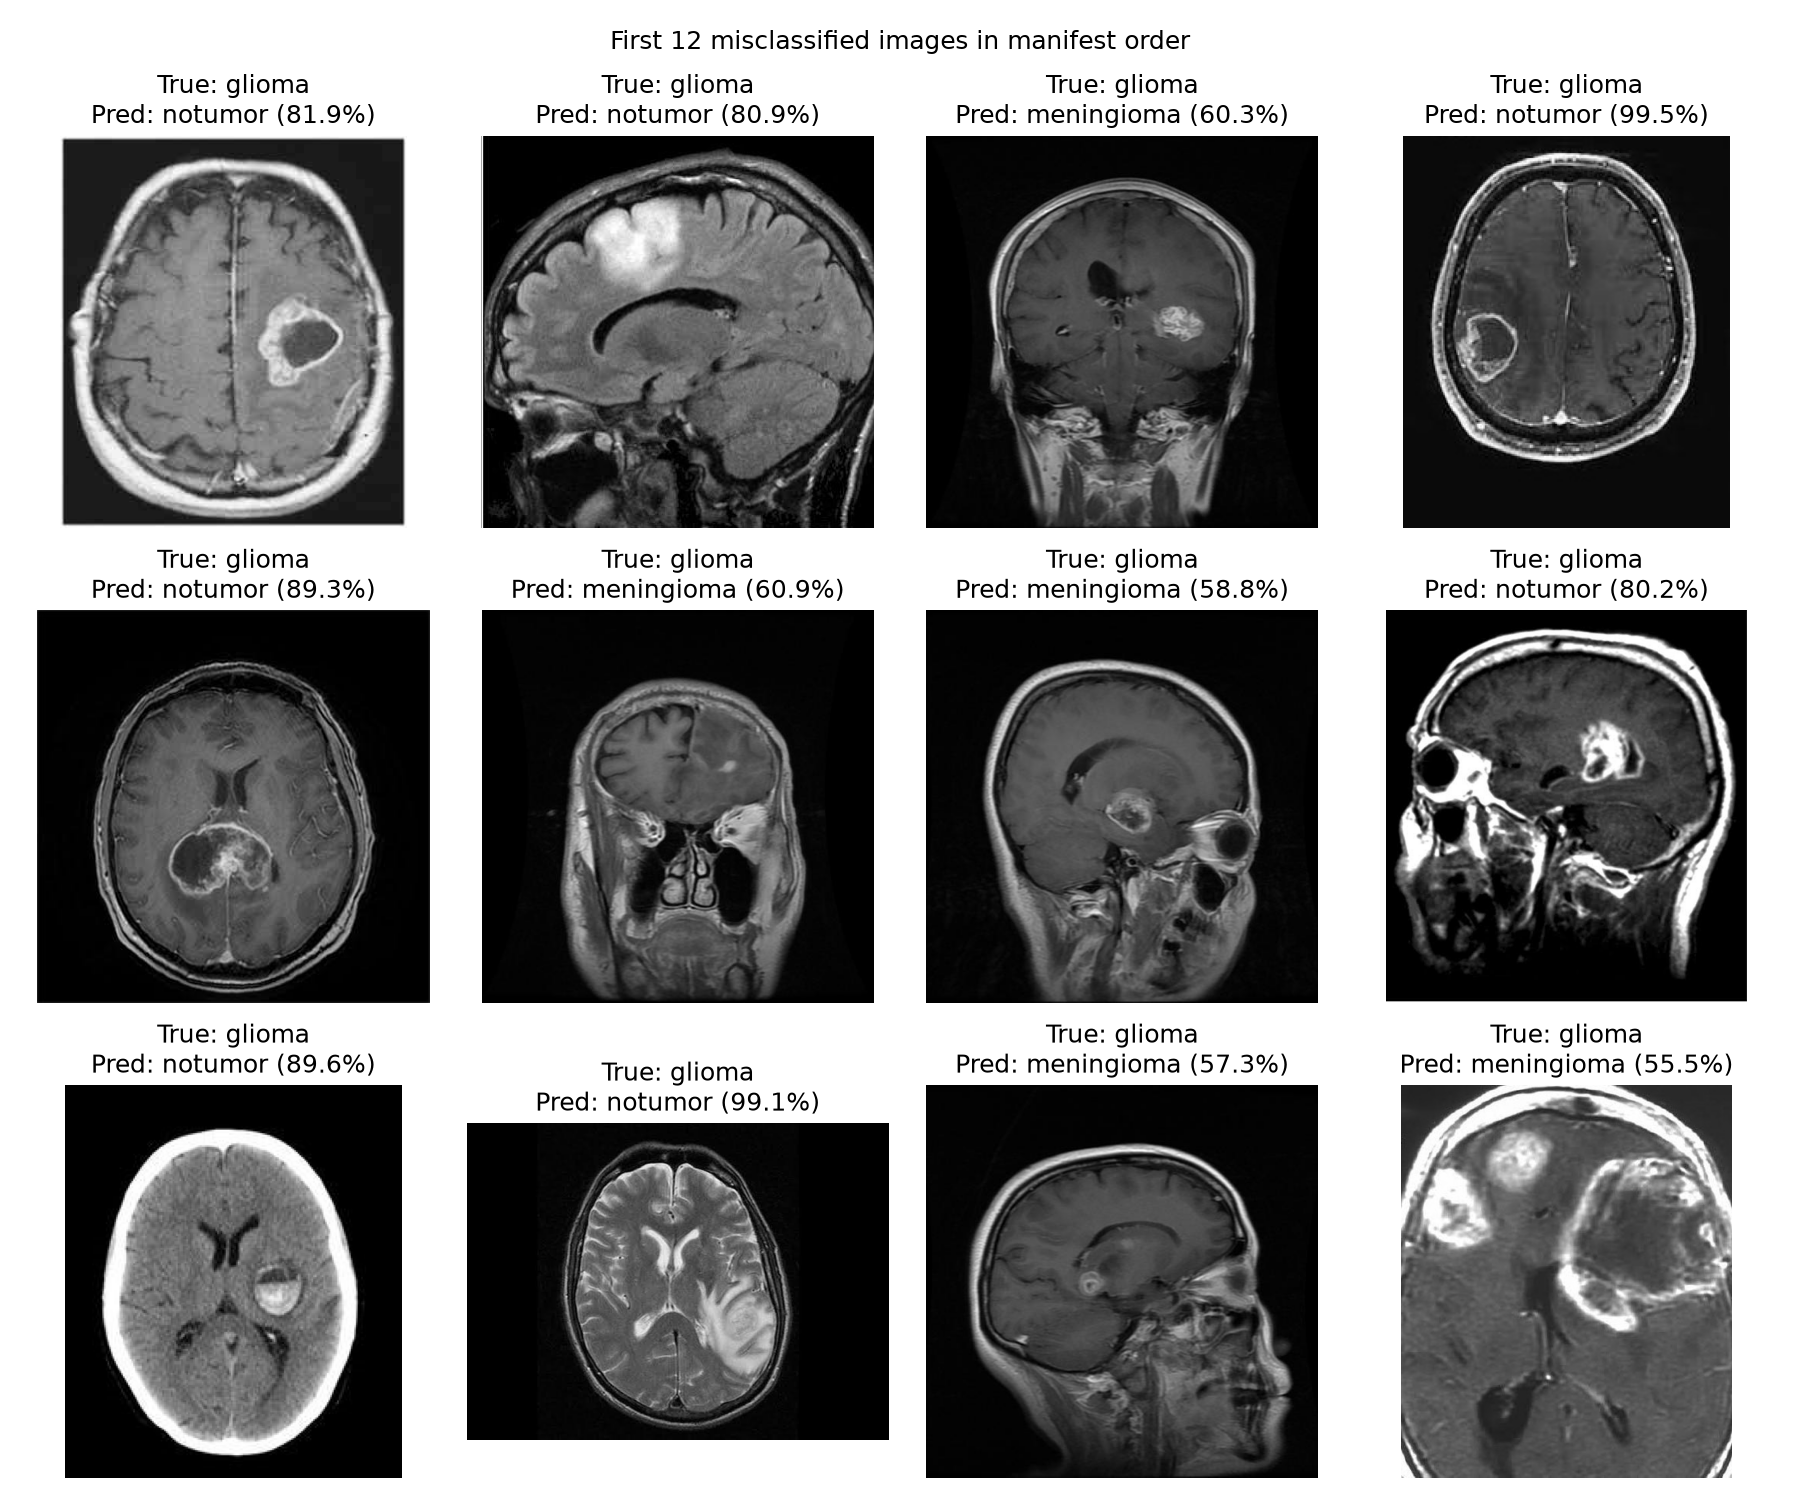

In [4]:
for name in ["confusion_matrix.png", "roc_curves.png", "misclassified_examples.png"]:
    if (output / name).exists():
        display(Image(filename=str(output / name)))
